In [165]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [146]:
path = "data/Algerian_forest_fires_dataset.csv"

In [147]:
dataset = pd.read_csv(path, header =1)
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [148]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.0 KB


**Data Cleaning**

In [149]:
dataset.isna().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [150]:
dataset[dataset.isna().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


The dataset contains two region data:
1. Bejaia Region Dataset
2. Sidi-Bel Abbes Region Dataset

we can make new column based on region

In [151]:
# adding new column based on region
dataset.loc[:122, "region"] = 0
dataset.loc[122:, "region"] = 1

# dropiing 122th row
dataset = dataset.drop([122,123], axis=0).reset_index(drop=True)
df = dataset

In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          244 non-null    str    
 1   month        244 non-null    str    
 2   year         244 non-null    str    
 3   Temperature  244 non-null    str    
 4    RH          244 non-null    str    
 5    Ws          244 non-null    str    
 6   Rain         244 non-null    str    
 7   FFMC         244 non-null    str    
 8   DMC          244 non-null    str    
 9   DC           244 non-null    str    
 10  ISI          244 non-null    str    
 11  BUI          244 non-null    str    
 12  FWI          244 non-null    str    
 13  Classes      243 non-null    str    
 14  region       244 non-null    float64
dtypes: float64(1), str(14)
memory usage: 28.7 KB


In [153]:
df["region"] = df["region"].astype('int32')
df.columns = df.columns.str.lower().str.strip()

In [154]:
df.isna().sum()

day            0
month          0
year           0
temperature    0
rh             0
ws             0
rain           0
ffmc           0
dmc            0
dc             0
isi            0
bui            0
fwi            0
classes        1
region         0
dtype: int64

In [155]:
# drop nan value
df.dropna(inplace=True)

Changing the other columns to float data datatype

In [156]:
cols = ['day', 'month', 'year', 'temperature', 'rh',
        'ws', 'rain', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi', 'region']
df[cols] = df[cols].astype('float32')

In [157]:
df.describe()

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152264,62.041153,15.493827,0.762963,77.842384,14.680658,49.430866,4.742387,16.690535,7.035390,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665607,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850002,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300003,11.300000,33.099998,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300003,20.800000,69.099998,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.799999,96.000000,65.900002,220.399994,19.000000,68.000000,31.100000,1.000000


In [158]:
## save clean data
df.to_csv("data/Algerian_forest_fires_cleaned_dataset.csv", index=False)

**Exploratory data analysis**

In [159]:
df_copy = df.drop(["day","month","year"], axis=1)

In [160]:
df_copy.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29.0,57.0,18.0,0.0,65.699997,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,29.0,61.0,13.0,1.3,64.400002,4.1,7.6,1.0,3.9,0.4,not fire,0.0
2,26.0,82.0,22.0,13.1,47.099998,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,25.0,89.0,13.0,2.5,28.600000,1.3,6.9,0.0,1.7,0.0,not fire,0.0
4,27.0,77.0,16.0,0.0,64.800003,3.0,14.2,1.2,3.9,0.5,not fire,0.0


In [161]:
df_copy["classes"]= df_copy["classes"].str.strip()
df_copy["classes"].value_counts()

classes
fire        137
not fire    106
Name: count, dtype: int64

In [162]:
df_copy["classes"]  = (df_copy["classes"] == 'fire').astype('int')

In [163]:
df_copy.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29.0,57.0,18.0,0.0,65.699997,3.4,7.6,1.3,3.4,0.5,0,0.0
1,29.0,61.0,13.0,1.3,64.400002,4.1,7.6,1.0,3.9,0.4,0,0.0
2,26.0,82.0,22.0,13.1,47.099998,2.5,7.1,0.3,2.7,0.1,0,0.0
3,25.0,89.0,13.0,2.5,28.600000,1.3,6.9,0.0,1.7,0.0,0,0.0
4,27.0,77.0,16.0,0.0,64.800003,3.0,14.2,1.2,3.9,0.5,0,0.0


In [164]:
df_copy["classes"].value_counts()

classes
1    137
0    106
Name: count, dtype: int64

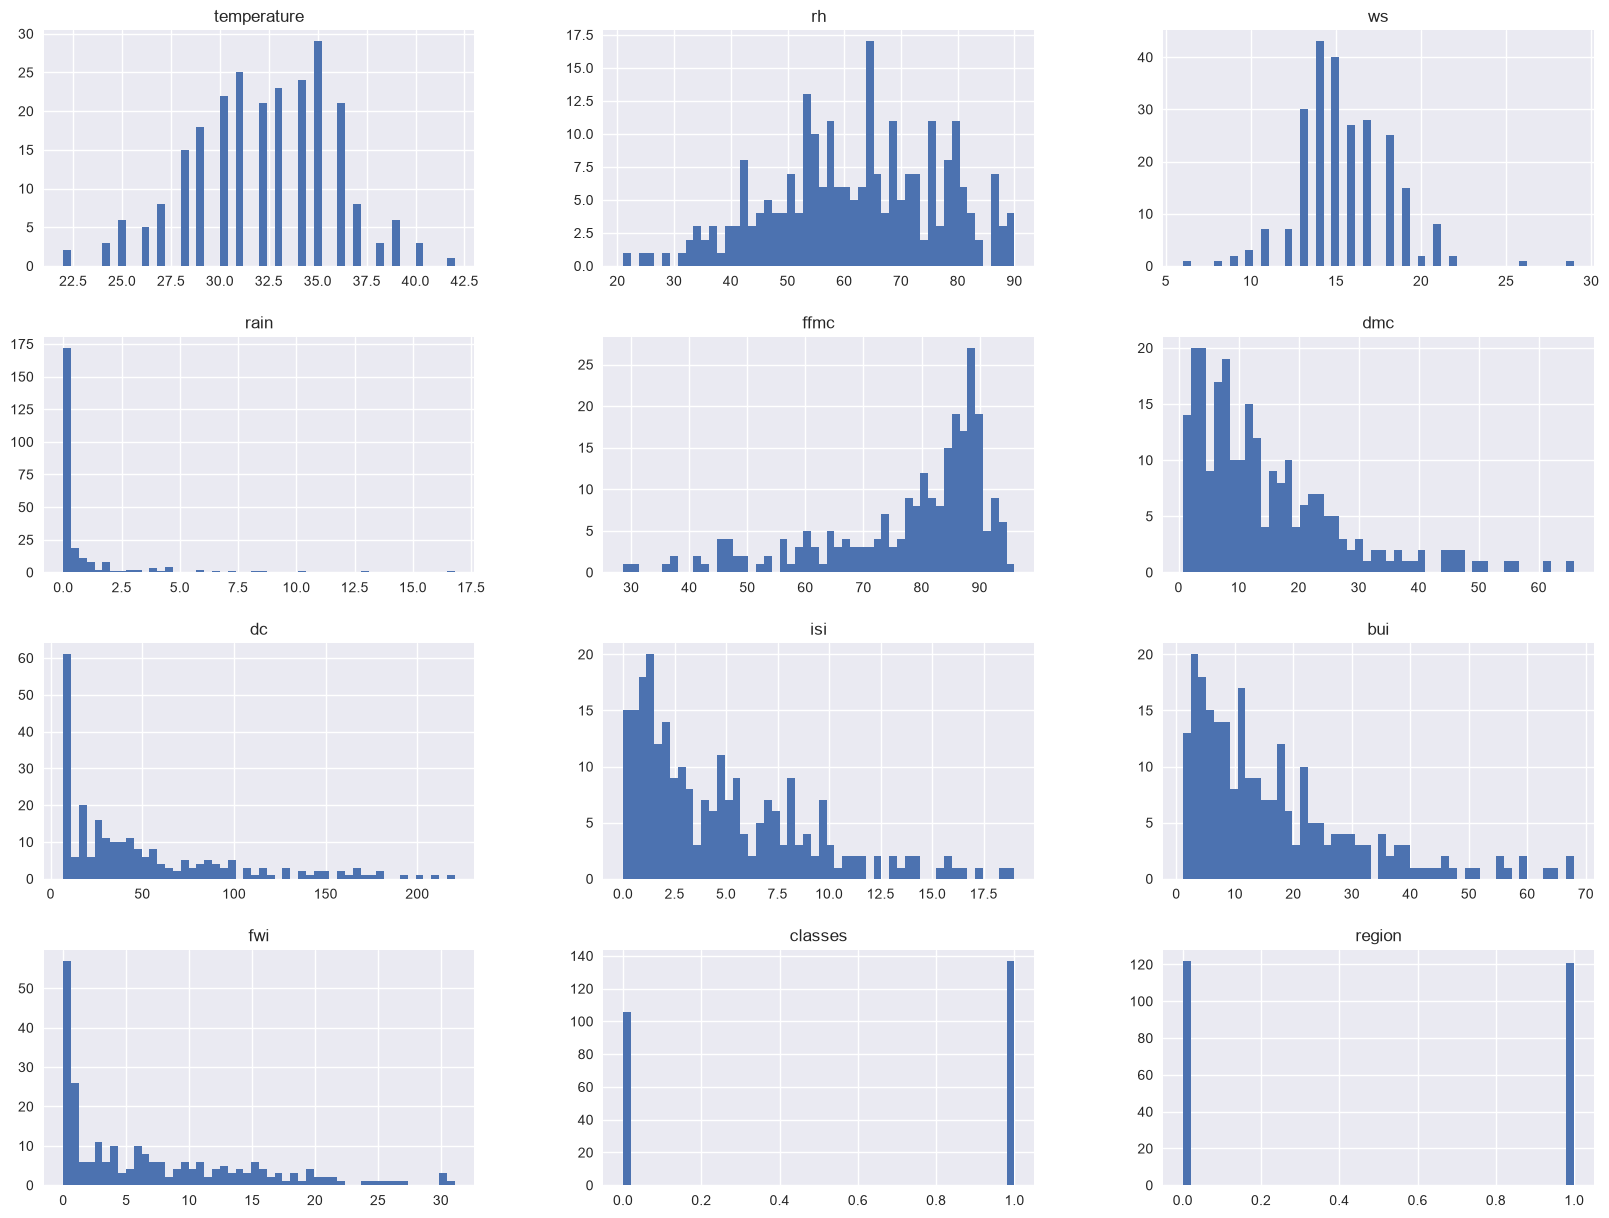

In [167]:
# plot density plot for all features
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50, figsize=(20, 15))
plt.show()

In [169]:
# percentage for the pie chart
percentage = df_copy["classes"].value_counts(normalize=True)
percentage

classes
1    0.563786
0    0.436214
Name: proportion, dtype: float64

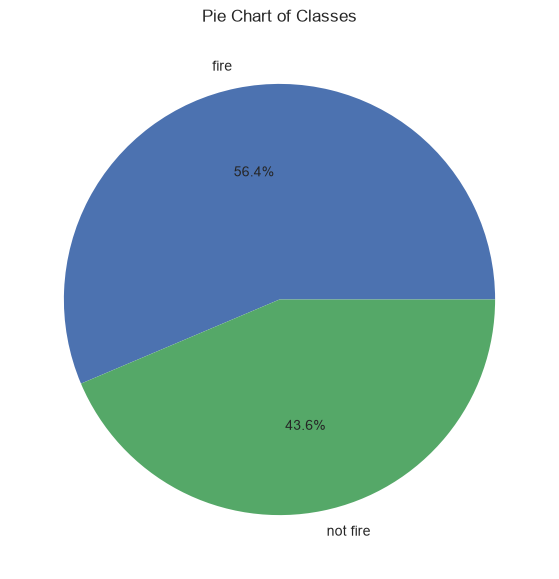

In [171]:
classlabels = ["fire", "not fire"]
plt.figure(figsize=(12, 7))
plt.pie(
    percentage,
    labels=classlabels,
    autopct="%1.1f%%"
)
plt.title("Pie Chart of Classes")
plt.show()

**Correlatrion**

In [172]:
df_copy.corr()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
rh,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
ffmc,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
dmc,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
dc,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
isi,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
bui,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
fwi,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

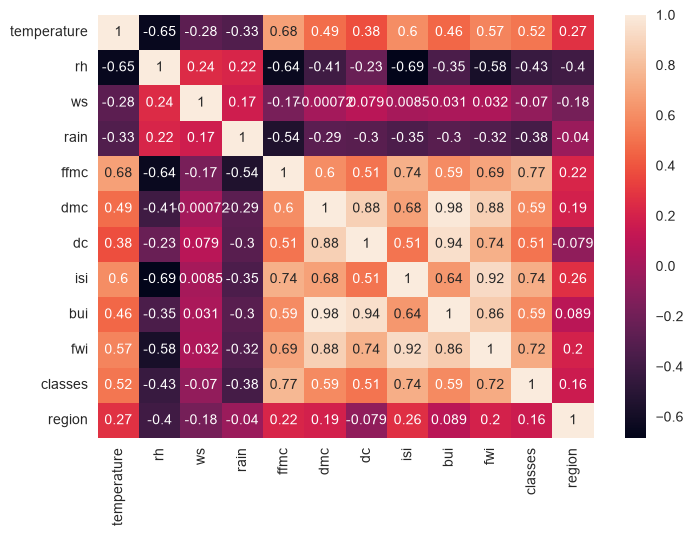

In [173]:
sns.heatmap(df_copy.corr(), annot=True)

In [187]:
df.classes = df.classes.str.strip()

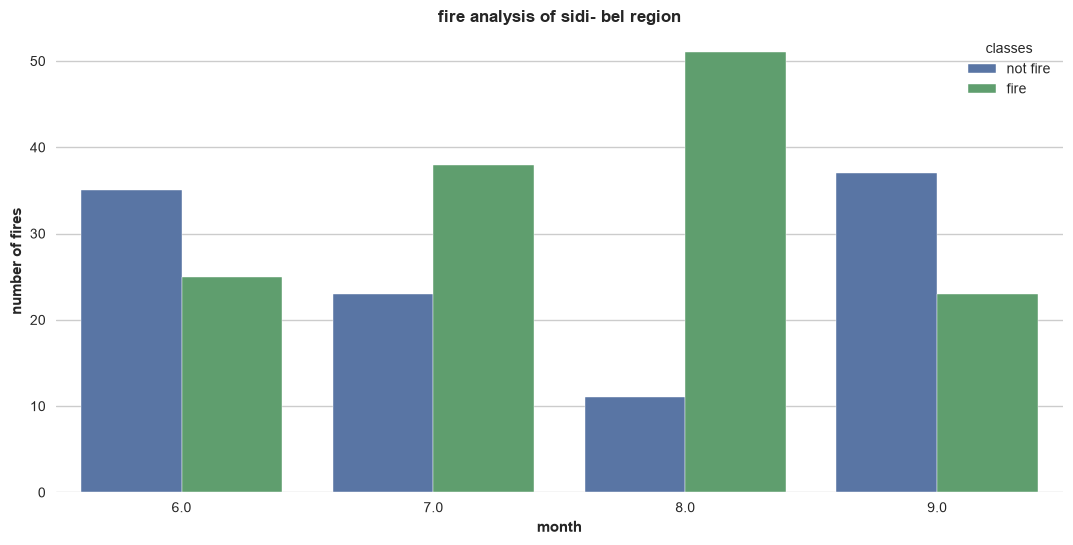

In [188]:
# monthly fire Anlaysis
df_temp = df.loc[df["region"]==1]
plt.subplots(figsize=(13,6))
sns.set_style("whitegrid")
sns.countplot(x='month',hue='classes',data= df)
plt.ylabel("number of fires", weight='bold')
plt.xlabel("month", weight='bold')
plt.title("fire analysis of sidi- bel region", weight='bold');

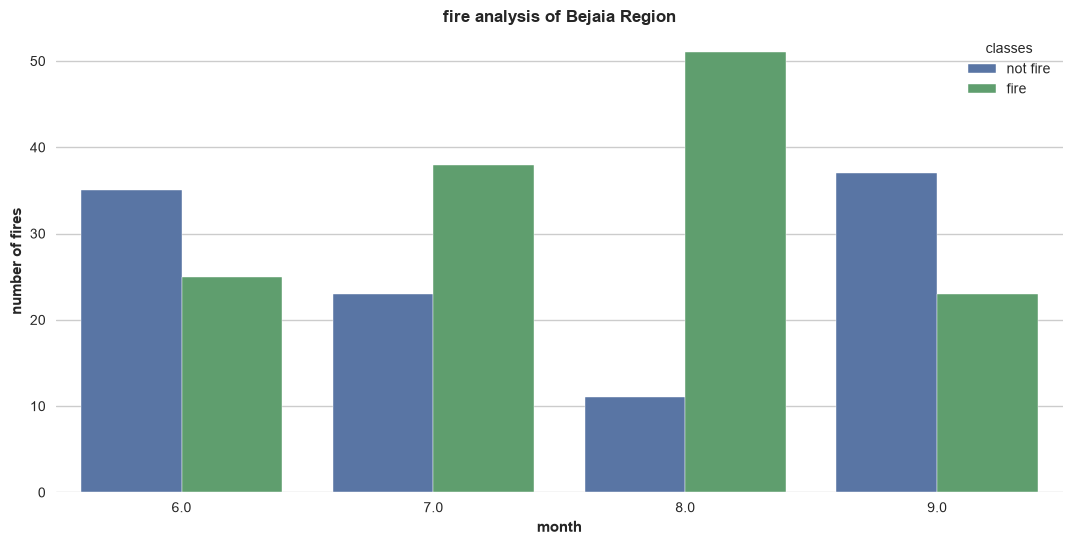

In [189]:
# monthly fire Anlaysis
df_temp = df.loc[df["region"]==0]
plt.subplots(figsize=(13,6))
sns.set_style("whitegrid")
sns.countplot(x='month',hue='classes',data= df)
plt.ylabel("number of fires", weight='bold')
plt.xlabel("month", weight='bold')
plt.title("fire analysis of Bejaia Region", weight='bold');